# Algorithmic Trading Backtester
## Building a strategy testing engine using real stock market data
##### Tools: Python, yfinance, Pandas, Matplotlib
##### Author: [Your Name]
##### Date: August 2026

In [1]:
pip install yfinance

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

In [3]:
data = yf.download("AAPL",start = "2020-01-01" , end = "2024-01-01")
data.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,
2020-01-02,72.271553,72.331709,71.029930,71.282583,135480400
2020-01-03,71.568909,72.326874,71.345130,71.501534,146322800
2020-01-06,72.139206,72.177707,70.442807,70.693058,118387200
2020-01-07,71.799911,72.403874,71.580942,72.148812,108872000
2020-01-08,72.954933,73.255714,71.503968,71.503968,132079200


In [4]:
data.shape

(1006, 5)

In [5]:
data.describe()

Price,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL
count,1006.000000,1006.000000,1006.000000,1006.000000,1.006000e+03
mean,137.712236,139.190655,136.085828,137.582427,9.895373e+07
std,33.298406,33.418284,33.159511,33.292152,5.439610e+07
min,54.117020,55.113158,51.280563,55.011856,2.404830e+07
25%,120.182556,121.421338,118.652365,120.287894,6.407675e+07
50%,142.561951,144.133022,140.903414,142.411987,8.467540e+07
75%,162.904308,165.176330,161.652945,163.171653,1.155069e+08
max,195.723801,197.215608,194.627166,195.634888,4.265100e+08


In [6]:
data.isna().sum()

Price   Ticker
Close   AAPL      0
High    AAPL      0
Low     AAPL      0
Open    AAPL      0
Volume  AAPL      0
dtype: int64

Text(0, 0.5, 'Closing Price')

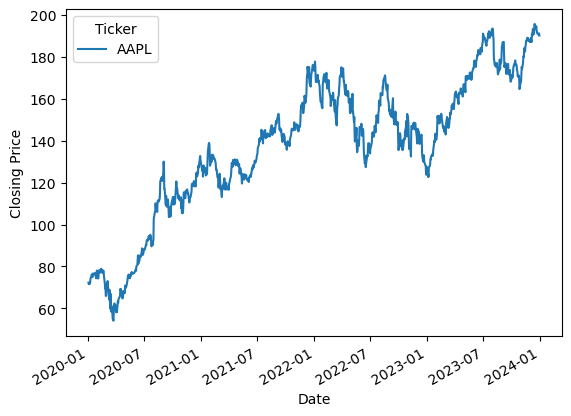

In [7]:
data['Close'].plot()
plt.xlabel('Date')
plt.ylabel('Closing Price')

In [8]:
data['return'] = data['Close'].pct_change()

In [9]:
data.head()

Price,Close,High,Low,Open,Volume,return
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,
Date,,,,,,
2020-01-02,72.271553,72.331709,71.029930,71.282583,135480400,NaN
2020-01-03,71.568909,72.326874,71.345130,71.501534,146322800,-0.009722
2020-01-06,72.139206,72.177707,70.442807,70.693058,118387200,0.007969
2020-01-07,71.799911,72.403874,71.580942,72.148812,108872000,-0.004703
2020-01-08,72.954933,73.255714,71.503968,71.503968,132079200,0.016087


In [10]:
data['return'].std()

0.021145909489508685

In [11]:
annualised_votality = data['return'].std() * (252 ** 0.5)

In [12]:
print(annualised_votality)

0.33568090653312466


In [13]:
data['MA50'] = data['Close'].rolling(window = 50).mean()

In [14]:
data.head(10)

Price,Close,High,Low,Open,Volume,return,MA50
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,
Date,,,,,,,
2020-01-02,72.271553,72.331709,71.029930,71.282583,135480400,NaN,NaN
2020-01-03,71.568909,72.326874,71.345130,71.501534,146322800,-0.009722,NaN
2020-01-06,72.139206,72.177707,70.442807,70.693058,118387200,0.007969,NaN
2020-01-07,71.799911,72.403874,71.580942,72.148812,108872000,-0.004703,NaN
2020-01-08,72.954933,73.255714,71.503968,71.503968,132079200,0.016087,NaN
2020-01-09,74.504539,74.697036,73.679200,73.929444,170108400,0.021241,NaN
2020-01-10,74.672966,75.236034,74.172470,74.737939,140644800,0.002261,NaN
2020-01-13,76.268311,76.294783,74.870283,74.988194,121532000,0.021364,NaN


In [15]:
data['MA200'] = data['Close'].rolling(window=200).mean()

In [16]:
data.tail(10)

Price,Close,High,Low,Open,Volume,return,MA50,MA200
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,
Date,,,,,,,,
2023-12-15,195.190308,196.010297,194.627166,195.150781,128538400,-0.002726,181.459467,175.047373
2023-12-18,193.530548,194.261640,192.048615,193.728136,55751900,-0.008503,181.827648,175.271986
2023-12-19,194.567932,194.577806,193.530576,193.797328,40714100,0.005360,182.186978,175.488010
2023-12-20,192.483337,195.299001,192.483337,194.528397,52242800,-0.010714,182.516456,175.704582
2023-12-21,192.335098,194.706200,191.169318,193.738008,46482500,-0.000770,182.815146,175.914165
2023-12-22,191.268127,193.056324,190.645711,192.829083,37149600,-0.005547,183.074539,176.129630
2023-12-26,190.724777,191.554656,190.507426,191.278030,28919300,-0.002841,183.359768,176.352660
2023-12-27,190.823563,191.169353,188.788377,190.171524,48087700,0.000518,183.649539,176.566493


In [17]:
data['Signal'] = np.where(data['MA50'] > data['MA200'], 1, 0)
#1 = BUY
#0 = SELL

In [18]:
data.tail()

Price,Close,High,Low,Open,Volume,return,MA50,MA200,Signal
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,
Date,,,,,,,,,
2023-12-22,191.268127,193.056324,190.645711,192.829083,37149600,-0.005547,183.074539,176.129630,1
2023-12-26,190.724777,191.554656,190.507426,191.278030,28919300,-0.002841,183.359768,176.352660,1
2023-12-27,190.823563,191.169353,188.788377,190.171524,48087700,0.000518,183.649539,176.566493,1
2023-12-28,191.248383,192.315376,190.843317,191.801635,34049900,0.002226,183.978787,176.772020,1
2023-12-29,190.211029,192.058501,189.420662,191.564523,42672100,-0.005424,184.313138,176.970392,1


In [19]:
data['Position'] = data['Signal'].diff()

In [20]:
data[data['Position'] != 0].dropna()

Price,Close,High,Low,Open,Volume,return,MA50,MA200,Signal,Position
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,,,,,
Date,,,,,,,,,,
2020-10-15,116.984642,117.459518,114.503651,115.056060,112559200,-0.003961,113.310525,85.649375,1,1.0
2022-06-03,142.396271,144.933111,141.495154,143.885064,88570300,-0.038556,155.680031,155.832539,0,-1.0
2022-09-26,147.880753,150.823263,146.772402,146.792023,93339400,0.002260,157.087758,157.051097,1,1.0
2022-10-07,137.405426,140.357754,136.777691,139.808473,85925600,-0.036718,155.624803,155.774528,0,-1.0
2023-03-22,155.299042,159.539924,155.279358,156.745470,75701800,-0.009103,145.312252,145.086298,1,1.0


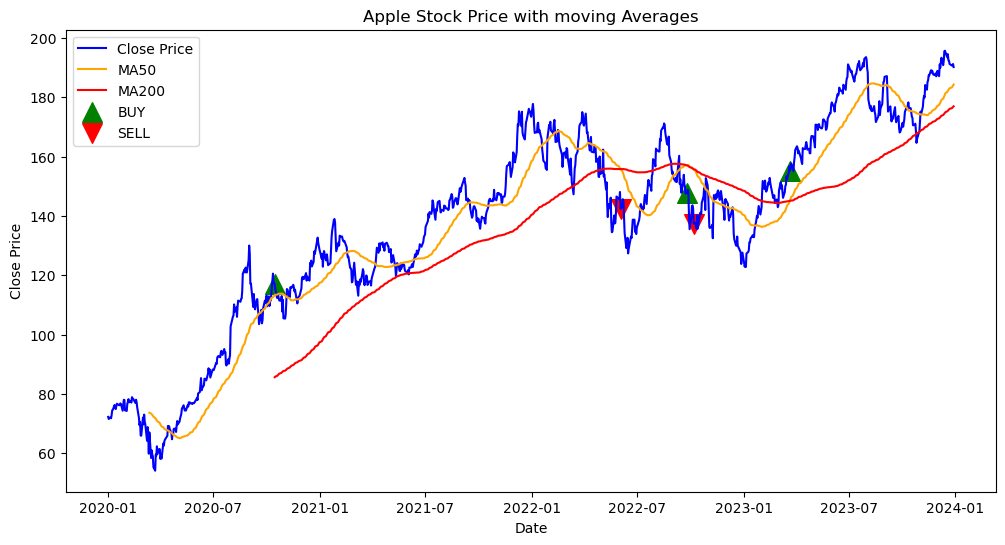

In [21]:
plt.figure(figsize=(12,6))

plt.plot(data.index, data['Close'], label='Close Price', color='blue')
plt.plot(data.index, data['MA50'], label='MA50', color='orange')
plt.plot(data.index, data['MA200'], label='MA200', color='red')

plt.scatter(data[data['Position'] == 1].index, 
            data[data['Position'] == 1]['Close'],
            marker = '^', color = 'green',label='BUY', s=200)
plt.scatter(data[data['Position'] == -1].index,
            data[data['Position'] == -1]['Close'],
            marker = 'v', color='red',label='SELL', s=200)
            

plt.xlabel('Date')
plt.ylabel('Close Price')
plt.title('Apple Stock Price with moving Averages')
plt.legend()
plt.show()